In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:

df = pd.read_csv('print_jobs.csv')
df

,material,orientation,supports,infill_pct,layer_height_mm,print_speed_mms,nozzle_temp_c,bed_temp_c,model_complexity,result
0,PETG,angled,no,15,0.20,169,246,82,moderate,success
1,PLA,flat,no,52,0.12,255,215,51,moderate,failure
2,PETG,angled,no,51,0.16,191,245,74,simple,failure
3,PETG,angled,no,33,0.12,195,230,86,complex,failure
4,PLA,vertical,no,21,0.16,95,227,35,moderate,failure
...,...,...,...,...,...,...,...,...,...,...
295,TPU,flat,no,80,0.20,34,229,25,moderate,success
296,TPU,angled,yes,95,0.20,37,220,44,moderate,success
297,PETG,angled,yes,88,0.16,187,233,76,simple,success
298,PETG,vertical,yes,78,0.20,135,259,89,complex,success


In [8]:
df.describe(include='object')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   material          300 non-null    object 
 1   orientation       300 non-null    object 
 2   supports          300 non-null    object 
 3   infill_pct        300 non-null    int64  
 4   layer_height_mm   300 non-null    float64
 5   print_speed_mms   300 non-null    int64  
 6   nozzle_temp_c     300 non-null    int64  
 7   bed_temp_c        300 non-null    int64  
 8   model_complexity  300 non-null    object 
 9   result            300 non-null    object 
dtypes: float64(1), int64(4), object(5)
memory usage: 23.6+ KB


In [6]:
df.isnull().sum()

material            0
orientation         0
supports            0
infill_pct          0
layer_height_mm     0
print_speed_mms     0
nozzle_temp_c       0
bed_temp_c          0
model_complexity    0
result              0
dtype: int64

In [7]:
df.head()

,material,orientation,supports,infill_pct,layer_height_mm,print_speed_mms,nozzle_temp_c,bed_temp_c,model_complexity,result
0,PETG,angled,no,15,0.20,169,246,82,moderate,success
1,PLA,flat,no,52,0.12,255,215,51,moderate,failure
2,PETG,angled,no,51,0.16,191,245,74,simple,failure
3,PETG,angled,no,33,0.12,195,230,86,complex,failure
4,PLA,vertical,no,21,0.16,95,227,35,moderate,failure


In [9]:
df.groupby("orientation")["result"].apply(lambda x: (x == "failure").mean())

orientation
angled      0.510204
flat        0.262069
vertical    0.403509
Name: result, dtype: float64

In [12]:
failure_by_orientation = df.groupby("orientation")["result"].apply(
    lambda x: (x == "failure").mean()
).reset_index()

failure_by_orientation.columns = ["orientation", "failure_rate"]

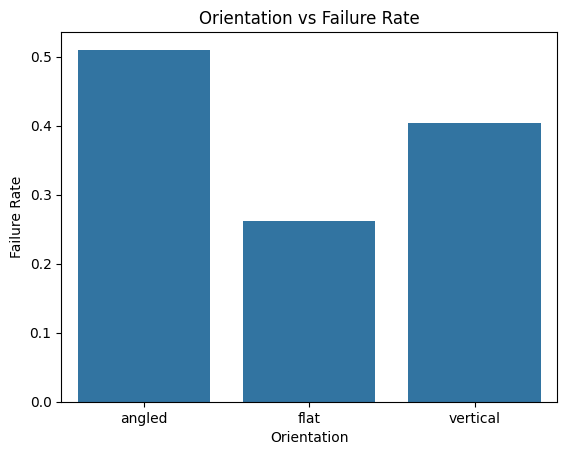

In [15]:
sns.barplot(data=failure_by_orientation, x="orientation", y="failure_rate")
plt.title("Orientation vs Failure Rate")
plt.xlabel("Orientation")
plt.ylabel("Failure Rate")
plt.show()

In [16]:
df.groupby(["orientation", "supports"])["result"].apply(lambda x: (x == "failure").mean())

orientation  supports
angled       no          0.711111
             yes         0.339623
flat         no          0.287234
             yes         0.215686
vertical     no          0.791667
             yes         0.121212
Name: result, dtype: float64

In [18]:
pivot = df.groupby(["orientation", "supports"])["result"].apply(
    lambda x: (x == "failure").mean()
).unstack()
pivot

supports,no,yes
orientation,,
angled,0.711111,0.339623
flat,0.287234,0.215686
vertical,0.791667,0.121212


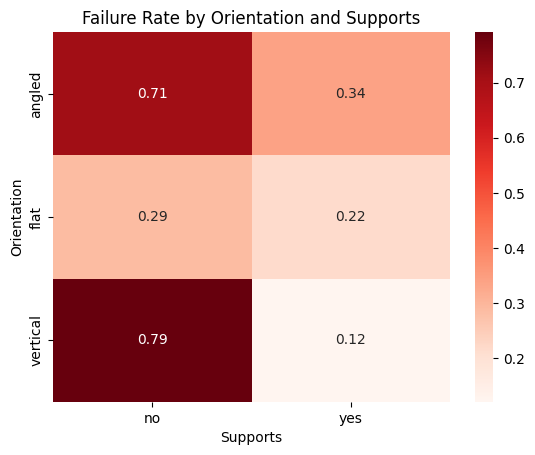

In [19]:
sns.heatmap(data=pivot, annot=True, fmt=".2f", cmap="Reds")
plt.title("Failure Rate by Orientation and Supports")
plt.xlabel("Supports")
plt.ylabel("Orientation")
plt.show()

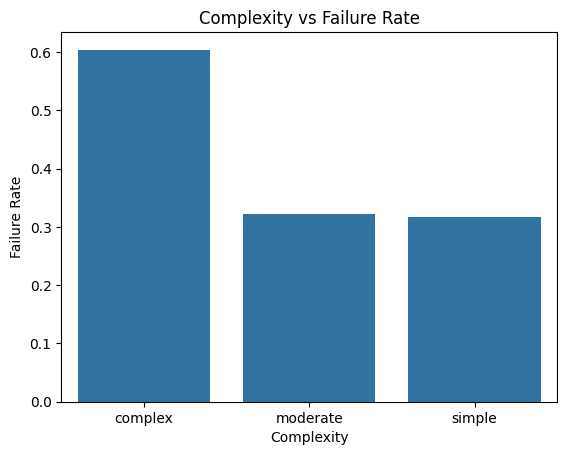

In [20]:
failure_by_complexity = df.groupby(["model_complexity"])["result"].apply(
    lambda x: (x == "failure").mean()
).reset_index()

failure_by_complexity.columns = ["complexity", "failure_rate"]

sns.barplot(data=failure_by_complexity, x="complexity", y="failure_rate")
plt.title("Complexity vs Failure Rate")
plt.xlabel("Complexity")
plt.ylabel("Failure Rate")
plt.show()

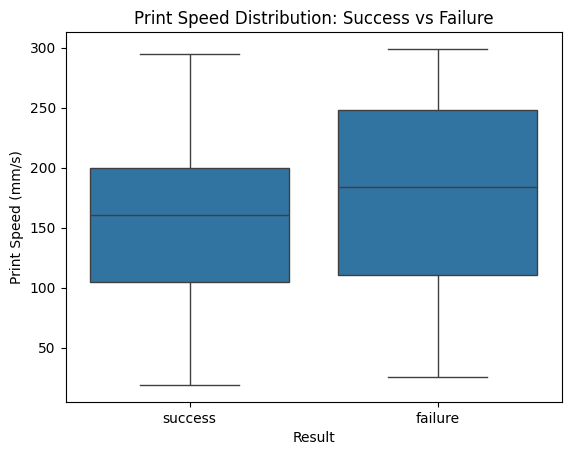

In [21]:
sns.boxplot(data=df, x="result", y="print_speed_mms")
plt.title("Print Speed Distribution: Success vs Failure")
plt.xlabel("Result")
plt.ylabel("Print Speed (mm/s)")
plt.show()

In [23]:
df["result_binary"] = df["result"].map({"success": 0, "failure": 1})
df.head()

,material,orientation,supports,infill_pct,layer_height_mm,print_speed_mms,nozzle_temp_c,bed_temp_c,model_complexity,result,result_binary
0,PETG,angled,no,15,0.20,169,246,82,moderate,success,0
1,PLA,flat,no,52,0.12,255,215,51,moderate,failure,1
2,PETG,angled,no,51,0.16,191,245,74,simple,failure,1
3,PETG,angled,no,33,0.12,195,230,86,complex,failure,1
4,PLA,vertical,no,21,0.16,95,227,35,moderate,failure,1


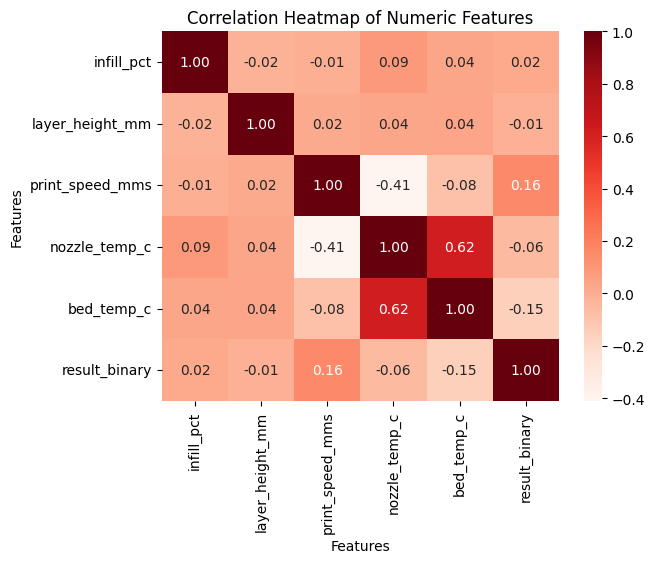

In [24]:
numeric_df = df[["infill_pct", "layer_height_mm", "print_speed_mms", 
                  "nozzle_temp_c", "bed_temp_c", "result_binary"]]

sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="Reds")
plt.title("Correlation Heatmap of Numeric Features")
plt.xlabel("Features")
plt.ylabel("Features")
plt.show()

In [25]:
df_encoded = pd.get_dummies(df, columns=["material", "orientation", "supports", "model_complexity"], drop_first=True)

In [26]:
df_encoded

,infill_pct,layer_height_mm,print_speed_mms,nozzle_temp_c,bed_temp_c,result,result_binary,material_PLA,material_TPU,orientation_flat,orientation_vertical,supports_yes,model_complexity_moderate,model_complexity_simple
0,15,0.20,169,246,82,success,0,False,False,False,False,False,True,False
1,52,0.12,255,215,51,failure,1,True,False,True,False,False,True,False
2,51,0.16,191,245,74,failure,1,False,False,False,False,False,False,True
3,33,0.12,195,230,86,failure,1,False,False,False,False,False,False,False
4,21,0.16,95,227,35,failure,1,True,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,80,0.20,34,229,25,success,0,False,True,True,False,False,True,False
296,95,0.20,37,220,44,success,0,False,True,False,False,True,True,False
297,88,0.16,187,233,76,success,0,False,False,False,False,True,False,True
298,78,0.20,135,259,89,success,0,False,False,False,True,True,False,False


In [28]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   infill_pct                 300 non-null    int64  
 1   layer_height_mm            300 non-null    float64
 2   print_speed_mms            300 non-null    int64  
 3   nozzle_temp_c              300 non-null    int64  
 4   bed_temp_c                 300 non-null    int64  
 5   result                     300 non-null    object 
 6   result_binary              300 non-null    int64  
 7   material_PLA               300 non-null    bool   
 8   material_TPU               300 non-null    bool   
 9   orientation_flat           300 non-null    bool   
 10  orientation_vertical       300 non-null    bool   
 11  supports_yes               300 non-null    bool   
 12  model_complexity_moderate  300 non-null    bool   
 13  model_complexity_simple    300 non-null    bool   

In [29]:
y = df_encoded["result_binary"]
X = df_encoded.drop(columns=["result", "result_binary"])
print(X.shape)
print(y.shape)

(300, 12)
(300,)


In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

c:\Users\Hello\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [33]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
lr_predictions = lr_model.predict(X_test)
rf_predictions = rf_model.predict(X_test)

In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix
lr_accuracy = accuracy_score(y_test, lr_predictions)
rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"Logistic Regression Accuracy: {lr_accuracy:.2f}")
print(f"Random Forest Accuracy: {rf_accuracy:.2f}")

Logistic Regression Accuracy: 0.77
Random Forest Accuracy: 0.78


In [37]:
lr_cm = confusion_matrix(y_test, lr_predictions)
rf_cm = confusion_matrix(y_test, rf_predictions)

print("Logistic Regression:")
print(lr_cm)
print("\nRandom Forest:")
print(rf_cm)

Logistic Regression:
[[32  5]
 [ 9 14]]

Random Forest:
[[36  1]
 [12 11]]


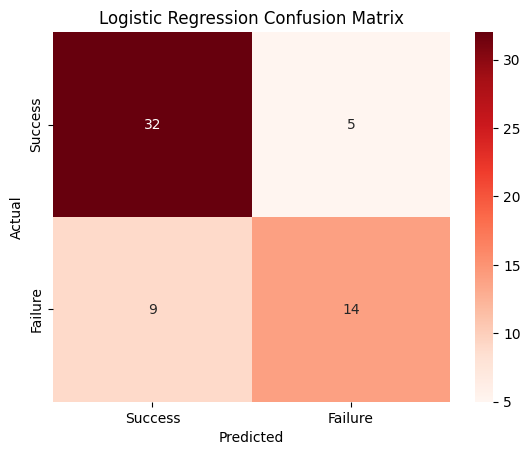

In [38]:
sns.heatmap(lr_cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Success", "Failure"],
            yticklabels=["Success", "Failure"])
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

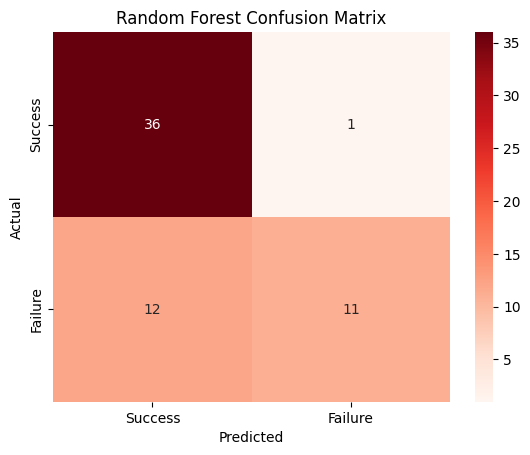

In [39]:
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Success", "Failure"],
            yticklabels=["Success", "Failure"])
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [40]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print(feature_importance)

                      feature  importance
4                  bed_temp_c    0.184607
2             print_speed_mms    0.181326
3               nozzle_temp_c    0.153946
0                  infill_pct    0.151463
1             layer_height_mm    0.095686
9                supports_yes    0.076629
7            orientation_flat    0.058025
11    model_complexity_simple    0.027784
10  model_complexity_moderate    0.027576
8        orientation_vertical    0.019749
5                material_PLA    0.015154
6                material_TPU    0.008054


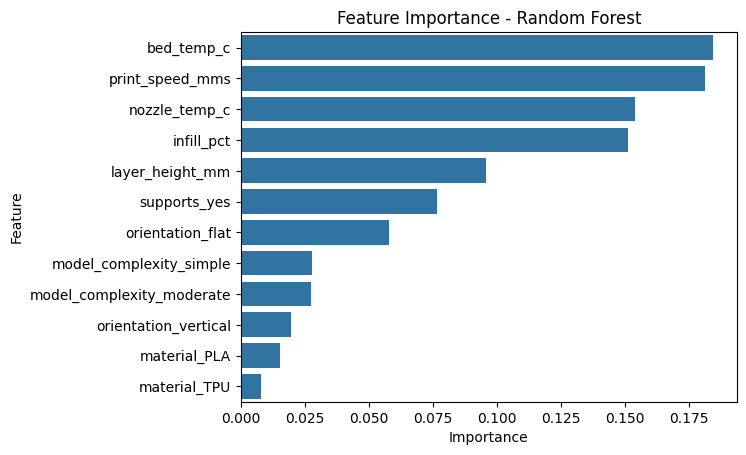

In [41]:
sns.barplot(data=feature_importance, x="importance", y="feature", orient="h")
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [46]:
def recommend(orientation, supports, print_speed, material, 
              layer_height, model_complexity):
    
    recommendations = []
    
   
    if orientation in ["vertical", "angled"] and supports == "no":
        recommendations.append("⚠️ Enable supports — vertical/angled prints without supports have 70-79% failure rate")
    
    
    if print_speed > 200:
        recommendations.append("⚠️ Reduce print speed below 200mm/s — high speed reduces interlayer bonding")
    
    
    if model_complexity == "complex" and supports == "no":
        recommendations.append("⚠️ Enable supports — complex models have high overhang risk")
    
    
    if material == "TPU" and print_speed > 50:
        recommendations.append("⚠️ Reduce print speed below 50mm/s — TPU is flexible and jams at high speeds")
    
    
    if layer_height <= 0.12 and print_speed > 180:
        recommendations.append("⚠️ Reduce print speed below 180mm/s or increase layer height — thin layers at high speed causes poor bonding")
    
    
    if len(recommendations) == 0:
        recommendations.append("✅ Settings look good — safe to print!")
    
    return recommendations



def predict_and_recommend(orientation, supports, print_speed,
                           material, layer_height, model_complexity,
                           nozzle_temp, bed_temp, infill_pct):

    
    input_dict = {
        "infill_pct": [infill_pct],
        "layer_height_mm": [layer_height],
        "print_speed_mms": [print_speed],
        "nozzle_temp_c": [nozzle_temp],
        "bed_temp_c": [bed_temp],
        "material_PLA": [1 if material == "PLA" else 0],
        "material_TPU": [1 if material == "TPU" else 0],
        "orientation_flat": [1 if orientation == "flat" else 0],
        "orientation_vertical": [1 if orientation == "vertical" else 0],
        "supports_yes": [1 if supports == "yes" else 0],
        "model_complexity_moderate": [1 if model_complexity == "moderate" else 0],
        "model_complexity_simple": [1 if model_complexity == "simple" else 0]
    }

   
    input_df = pd.DataFrame(input_dict)

    
    prediction = rf_model.predict(input_df)[0]
    probability = rf_model.predict_proba(input_df)[0][1]

    
    recs = recommend(orientation, supports, print_speed,
                     material, layer_height, model_complexity)

    
    print(f"Prediction  : {'❌ FAILURE' if prediction == 1 else '✅ SUCCESS'}")
    print(f"Failure Probability: {probability:.1%}")
    print("\nRecommendations:")
    for r in recs:
        print(r)




In [47]:
predict_and_recommend(
    orientation="vertical",
    supports="no",
    print_speed=280,
    material="TPU",
    layer_height=0.12,
    model_complexity="complex",
    nozzle_temp=220,
    bed_temp=40,
    infill_pct=80
)

Prediction  : ❌ FAILURE
Failure Probability: 75.0%

Recommendations:
⚠️ Enable supports — vertical/angled prints without supports have 70-79% failure rate
⚠️ Reduce print speed below 200mm/s — high speed reduces interlayer bonding
⚠️ Enable supports — complex models have high overhang risk
⚠️ Reduce print speed below 50mm/s — TPU is flexible and jams at high speeds
⚠️ Reduce print speed below 180mm/s or increase layer height — thin layers at high speed causes poor bonding


In [48]:
predict_and_recommend(
    orientation="flat",
    supports="yes",
    print_speed=150,
    material="PLA",
    layer_height=0.20,
    model_complexity="simple",
    nozzle_temp=210,
    bed_temp=55,
    infill_pct=20
)

Prediction  : ✅ SUCCESS
Failure Probability: 20.0%

Recommendations:
✅ Settings look good — safe to print!


In [49]:
import joblib
joblib.dump(rf_model, "rf_model.pkl")

['rf_model.pkl']